In [10]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#disable scientifical notation
pd.options.display.float_format = '{:.2f}'.format


# Extract and Transform

In [11]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/google/meridian/refs/heads/main/meridian/data/simulated_data/csv/geo_all_channels.csv"
)
df = df.iloc[:, 1:]
df = df[df["geo"]=="Geo0"]
df = df.drop(columns=["geo", "time", "revenue_per_conversion", "competitor_sales_control", "Channel0_impression", "Channel1_impression", "Channel2_impression", "Channel3_impression", "Channel4_impression", "sentiment_score_control", "Organic_channel0_impression", "population"])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 0 to 155
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Channel0_spend  156 non-null    float64
 1   Channel1_spend  156 non-null    float64
 2   Channel2_spend  156 non-null    float64
 3   Channel3_spend  156 non-null    float64
 4   Channel4_spend  156 non-null    float64
 5   Promo           156 non-null    float64
 6   conversions     156 non-null    float64
dtypes: float64(7)
memory usage: 9.8 KB


In [13]:
df.describe()

,Channel0_spend,Channel1_spend,Channel2_spend,Channel3_spend,Channel4_spend,Promo,conversions
count,156.00,156.00,156.00,156.00,156.00,156.00,156.00
mean,1581.75,1383.26,478.27,3500.56,1799.84,0.45,2313344.05
std,1147.87,1345.18,868.11,1736.43,1411.34,0.66,775979.27
min,0.00,0.00,0.00,0.00,0.00,0.00,643680.50
25%,556.95,35.47,0.00,2307.61,481.42,0.00,1770323.03
50%,1542.46,1122.70,0.00,3268.46,1652.71,0.01,2325947.25
75%,2307.69,2222.75,765.47,4626.32,2782.84,0.80,2796895.33
max,4563.93,5566.14,3575.40,7670.84,6237.18,2.75,4339777.00


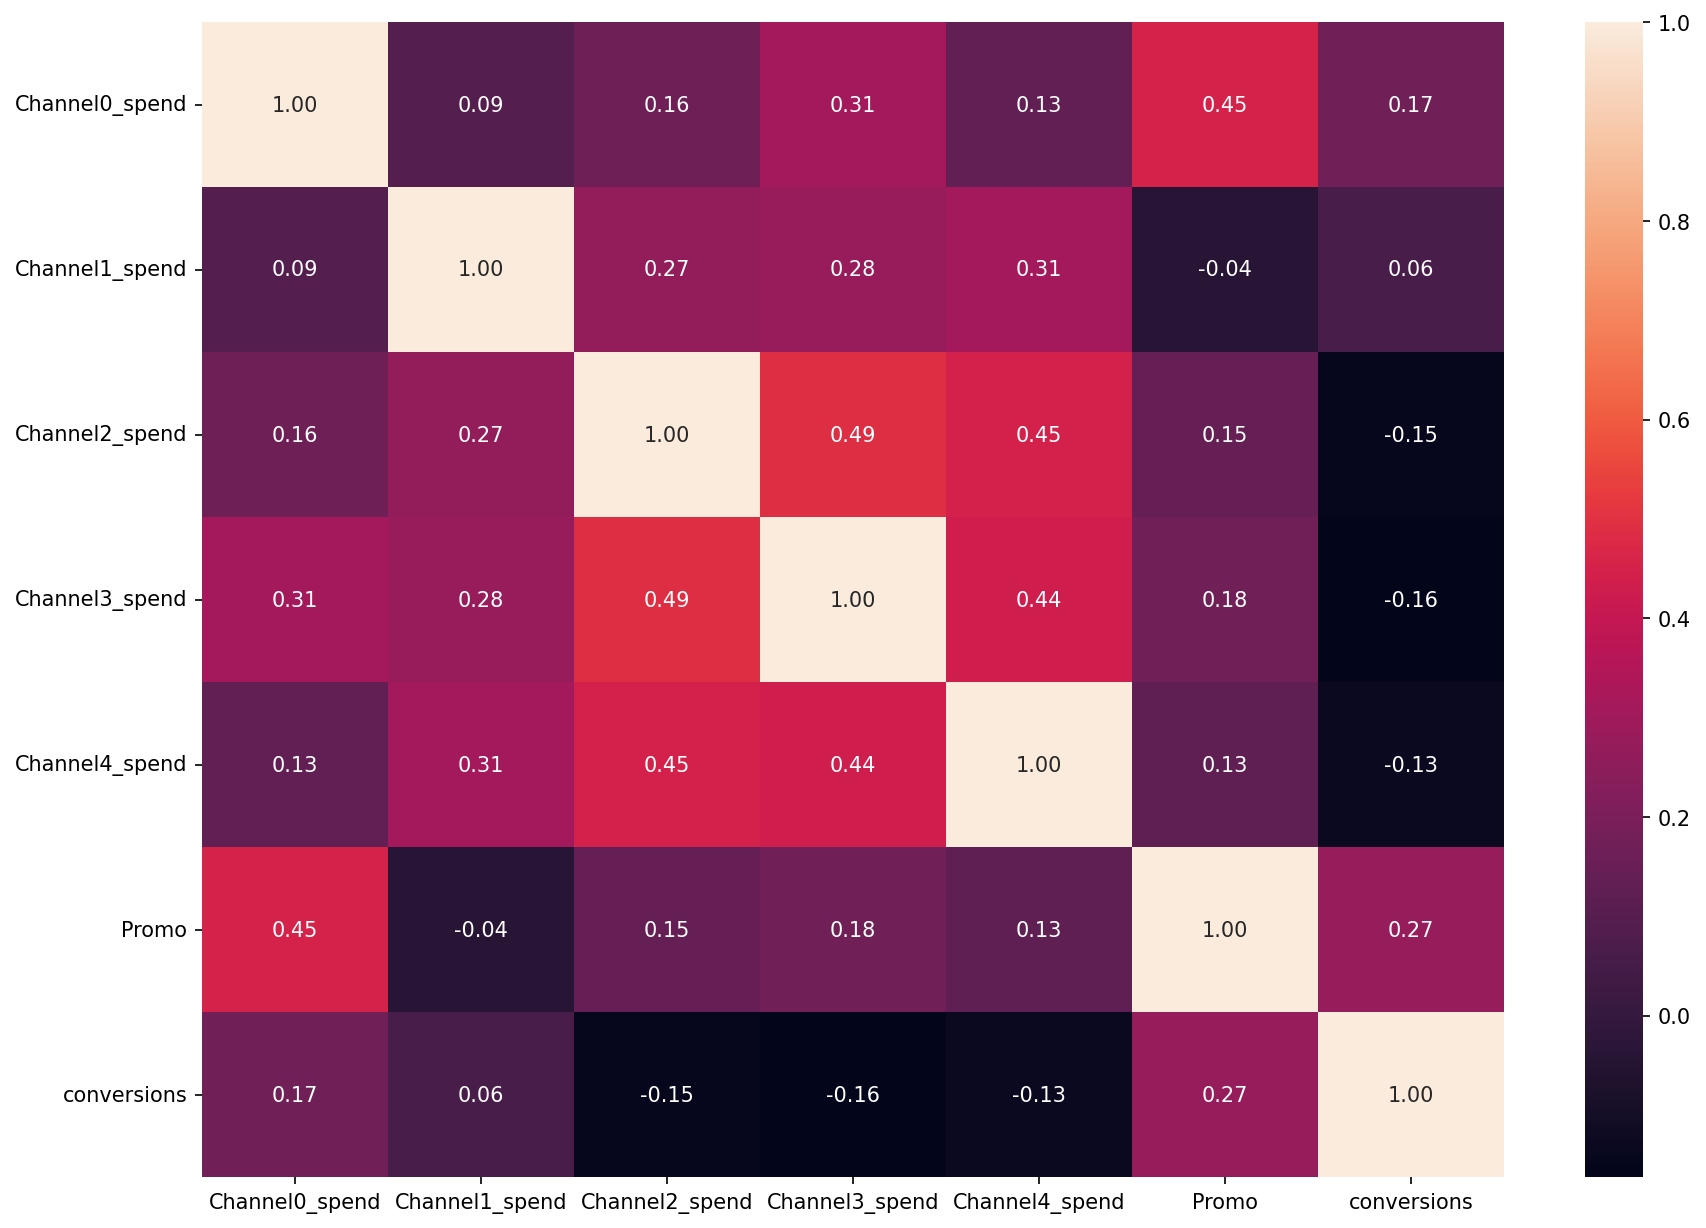

In [14]:
plt.figure(figsize=(14, 10), dpi=150)
sns.heatmap( df.select_dtypes(include=["int64", "float64"]).corr(), annot=True, fmt=".2f")
plt.show()


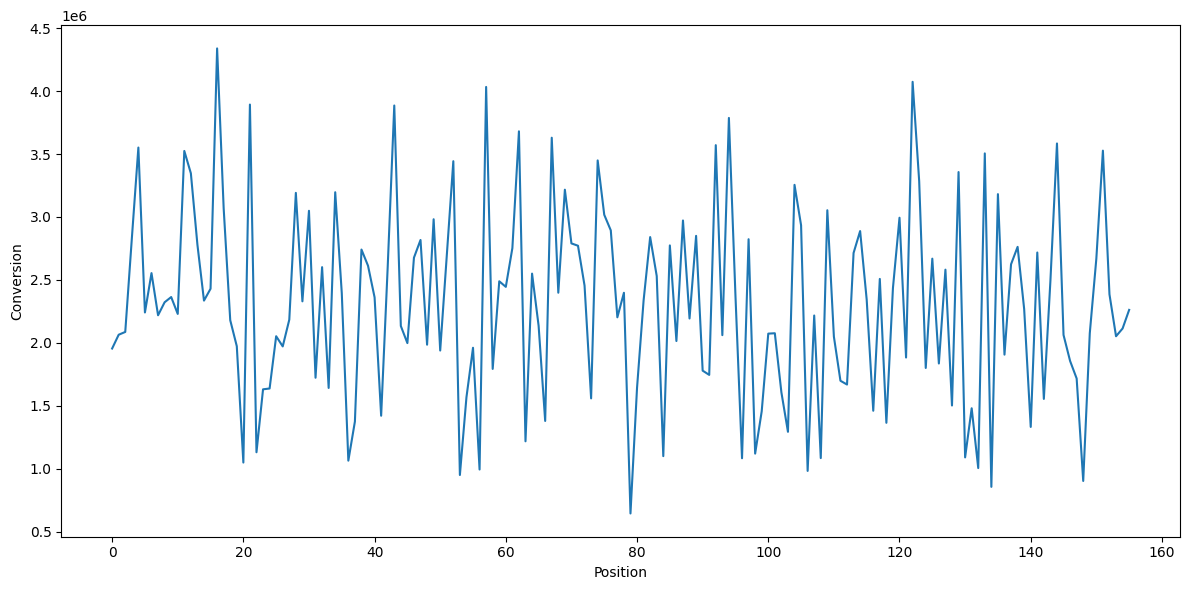

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y=df["conversions"])
plt.xlabel("Position")
plt.ylabel("Conversion")
plt.tight_layout()
plt.show()

# Adstock and saturation
## alpha (adstock / memory)
Controls how much past advertising persists.
- tv: 0.70 → strong memory (TV has long carryover)  
- search: 0.30 → short memory (intent-driven)  
- social: 0.50 → medium memory

## lam (saturation speed)
Controls diminishing returns.
- low lam → slow saturation (needs a lot of spend)  
- high lam → fast saturation (plateaus quickly)

In [16]:
def adstock_geometric(x, alpha):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    for t in range(len(x)):
        out[t] = x[t] + (out[t-1] * alpha if t > 0 else 0.0)
    return out

def saturation_exp(x, lam):
    x = np.asarray(x, dtype=float)
    return 1 - np.exp(-lam * x)

def transform_media(x, alpha, lam, scale="mean", eps=1e-8):
    x_ad = adstock_geometric(x, alpha)

    # normalize BEFORE saturation
    if scale == "mean":
        denom = np.mean(x_ad) + eps
    elif scale == "max":
        denom = np.max(x_ad) + eps
    else:
        denom = 1.0

    x_scaled = x_ad / denom
    return saturation_exp(x_scaled, lam)

In [17]:

media_params = {
    "Channel0_spend": {"alpha": 0.70, "lam": 0.02},
    "Channel1_spend": {"alpha": 0.30, "lam": 0.05},
    "Channel2_spend": {"alpha": 0.50, "lam": 0.04},
    "Channel3_spend": {"alpha": 0.50, "lam": 0.04},
    "Channel4_spend": {"alpha": 0.50, "lam": 0.04},

}

for ch, p in media_params.items():
    df[f"{ch}_mm"] = transform_media(df[ch].to_numpy(), p["alpha"], p["lam"])

In [18]:
df

,Channel0_spend,Channel1_spend,Channel2_spend,Channel3_spend,Channel4_spend,Promo,conversions,Channel0_spend_mm,Channel1_spend_mm,Channel2_spend_mm,Channel3_spend_mm,Channel4_spend_mm
0,2058.06,0.00,0.00,3667.40,841.60,0.00,1954576.80,0.01,0.00,0.00,0.02,0.01
1,2685.29,1755.75,147.32,4112.30,1967.50,0.00,2064249.60,0.02,0.04,0.01,0.03,0.03
2,1448.69,2219.12,0.00,3067.40,1434.19,0.68,2086382.80,0.02,0.07,0.00,0.03,0.03
3,1033.84,642.52,0.00,2540.73,1571.85,1.29,2826431.50,0.02,0.04,0.00,0.03,0.03
4,2926.61,1590.72,0.00,2976.72,1199.74,0.23,3551929.20,0.02,0.05,0.00,0.03,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...
151,0.00,2949.94,0.00,3326.56,1170.20,0.00,3527291.20,0.02,0.07,0.02,0.04,0.02
152,480.53,0.00,1166.22,1744.29,1296.43,0.00,2385392.20,0.01,0.02,0.06,0.03,0.02
153,342.34,0.00,0.00,4602.44,769.96,0.00,2052164.90,0.01,0.01,0.03,0.04,0.02
154,510.81,1814.44,0.00,0.00,213.72,0.00,2113785.80,0.01,0.05,0.01,0.02,0.01


# Model

In [19]:
target ="conversions"
X = df.drop(columns=[target])   # features
y = df[target]                      # target

In [20]:
#regularization hyperparameter
alphas = np.logspace(-3, 3, 50)
tscv = TimeSeriesSplit(n_splits=5)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=tscv))
])

pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.",array([1.0000...00000000e+03])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yield

In [21]:
best_alpha = pipe.named_steps["ridge"].alpha_
print("best alpha:", best_alpha)


best alpha: 33.9322177189533


In [22]:
pred = np.empty(len(y))
pred[:] = np.nan

for train_idx, test_idx in tscv.split(X):
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    pred[test_idx] = pipe.predict(X.iloc[test_idx])

mask = ~np.isnan(pred)
print("MAE:", mean_absolute_error(y[mask], pred[mask]))
print("R2 :", r2_score(y[mask], pred[mask]))

MAE: 607357.6217178749
R2 : 0.04151415600386732


In [23]:
ridge = pipe.named_steps["ridge"]
coef = pd.Series(ridge.coef_, index=X.columns).sort_values(ascending=False)
print(coef.head(20))

Promo                155133.25
Channel0_spend        63992.89
Channel0_spend_mm     53840.75
Channel1_spend_mm     45389.83
Channel1_spend        43282.80
Channel2_spend_mm      1859.22
Channel4_spend_mm     -6979.27
Channel3_spend_mm    -30486.51
Channel2_spend       -46867.13
Channel4_spend       -51151.58
Channel3_spend      -118480.99
dtype: float64


In [24]:
media_cols = ["Channel0_spend", "Channel1_spend", "Channel2_spend", "Channel3_spend", "Channel4_spend"]  # adapt to your names

X_full = X.copy()
y_hat = pipe.predict(X_full)

# baseline: no media
X_base = X_full.copy()
X_base[media_cols] = 0.0
baseline = pipe.predict(X_base)

contrib = {}
for ch in media_cols:
    X_zero = X_full.copy()
    X_zero[ch] = 0.0
    contrib[ch] = y_hat - pipe.predict(X_zero)

contrib_df = pd.DataFrame(contrib)
contrib_df["baseline"] = baseline
contrib_df["pred"] = y_hat

In [25]:
roi_rows = []
for ch in media_cols:
    spend_col = ch.replace("_mm", "")
    inc = contrib_df[ch].sum()          # incremental outcome (e.g., revenue)
    spend = df[spend_col].sum()
    roi_rows.append([spend_col, inc, spend, inc / spend if spend else np.nan])

roi_df = pd.DataFrame(roi_rows, columns=["channel", "incremental", "spend", "ROI"]).sort_values("ROI", ascending=False)
roi_df

,channel,incremental,spend,ROI
0,Channel0_spend,13730332.41,246753.58,55.64
1,Channel1_spend,6844756.71,215788.84,31.72
4,Channel4_spend,-10131754.45,280774.82,-36.08
2,Channel2_spend,-4606840.96,74610.83,-61.74
3,Channel3_spend,-38119031.39,546086.98,-69.80


In [ ]:
plt.figure()
plt.bar(roi_df["channel"], roi_df["ROI"])
plt.axhline(1, linestyle="--")  # break-even ROI
plt.title("ROI by channel")
plt.ylabel("ROI")
plt.xlabel("Channel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


IndentationError: unexpected indent (3607377939.py, line 1)